# **Chest X-Ray YOLO Model Training Example**

This notebook is an example demonstrating how to load and explore the Chest X-ray dataset used for training a Deep Learning model. The dataset comprises 112,120 frontal-view X-ray images from 30,805 unique patients. Each image may have multi-label annotations for the following fourteen thoracic pathologies:

- Atelectasis
- Consolidation
- Infiltration
- Pneumothorax
- Edema
- Emphysema
- Fibrosis
- Effusion
- Pneumonia
- Pleural Thickening
- Cardiomegaly
- Nodule
- Mass
- Hernia

The focus of this notebook is solely on data loading and preliminary exploration.

# Clean environment

In [1]:
!rm -rf sample_data
# !rm -rf datasets/data

# Libraries

If you're using Google Colab, just run the next cell. If you're using a local notebook (e.g., inside of VSC), change the cell language mode to Batch or similar.

In [2]:
!pip install huggingface_hub pandas keras

# Getting the dataset

You can either use the complete dataset (more than 40 GB will be needed) or a 17 GB dataset created from the original that is stored on Google Drive and can be mounted in order to load it quickly.

**Important**: The download size of the complete dataset is around 40 GB.

In [3]:
import pandas as pd
import os
import zipfile
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
from glob import glob
from itertools import chain
from matplotlib import pyplot as plt

In [ ]:
HUGGING_FACE = "hugging_face"
GOOGLE_DRIVE = "google_drive"

# Modify this variable to change the dataset download mode
DATASET_DOWNLOAD_MODE = HUGGING_FACE

if DATASET_DOWNLOAD_MODE == HUGGING_FACE:
    from huggingface_hub import hf_hub_download

    REPO_ID = "alkzar90/NIH-Chest-X-ray-dataset"
    FILEPATH = "data/Data_Entry_2017_v2020.csv"

    datasets_path = Path("datasets/").mkdir(exist_ok=True)
    dataset_path = Path(hf_hub_download(repo_id=REPO_ID, filename=FILEPATH, repo_type="dataset", local_dir="datasets/"))

    # Download images
    for i in range(1, 12+1):
        FILEPATH = f"data/images/images_{i:03d}.zip"
        downloaded_tmp_file = Path("datasets/") / "tmp" / f"zip-{i}-downloaded.tmp"

        if downloaded_tmp_file.exists():
            print(f"{FILEPATH} already exists. Skipping download.")
        else:
            print(f"Downloading {FILEPATH}...")
            zip_path = Path(hf_hub_download(
                repo_id=REPO_ID, filename=FILEPATH, repo_type="dataset", local_dir="datasets/"))

            # Create a temp file that indicates the zip was completely downloaded
            downloaded_tmp_file.mkdir(parents=True, exist_ok=True)
            downloaded_tmp_file.touch()

        extracted_tmp_file = Path("datasets/") / "tmp" / f"zip-{i}-extracted.tmp"
        if extracted_tmp_file.exists():
            print(f"{FILEPATH} already exists. Skipping download.")
        else:
            zipfile.ZipFile(zip_path).extractall("datasets/data/")

            # Create a temp file that indicates the zip was completely extracted
            extracted_tmp_file.mkdir(parents=True, exist_ok=True)
            extracted_tmp_file.touch()

            os.system(f"rm datasets/{FILEPATH}")

            print("ZIP extracted and removed!")

    print("Dataset downloaded and extracted!")

# TODO: Implement Google Drive mount
# elif DATASET_DOWNLOAD_MODE == GOOGLE_DRIVE:
#     from google.colab import drive
#     drive.mount('/content/drive')

# Data Exploration

In [5]:
# !ls datasets/data/images

## Clean and transform the data

In [ ]:
csv = pd.read_csv(dataset_path)

# Add an image_path column to the DataFrame
images_paths = {
    os.path.basename(x): x for x in
        glob(os.path.join('.', 'datasets', 'data', 'images', '*.png'))
}

print(f'Found {len(images_paths)} images. Total Rows: {csv.shape[0]}')
csv['image_path'] = csv['Image Index'].map(images_paths.get)

# Remove rows that have a null path
csv.dropna(subset=['image_path'], inplace=True)
print(f"Dropped rows with a null path. {csv.shape[0]} rows remain.")

# Remove 'No Finding' labels from the Finding Labels column
csv['Finding Labels'] = csv['Finding Labels'].map(lambda x: x.replace('No Finding', ''))

# Get all labels ['Label1', 'Label3', 'Label1', ...]
all_labels = list(chain(*csv['Finding Labels'].map(lambda x: x.split('|')).tolist()))
# Get unique {'Label1', 'Label2', 'Label3', ...}
all_labels = list(set(all_labels))
# Remove empty string label
all_labels.remove('')

# Add each label as a column and set 1 if the label was assigned to the image;
# otherwise, set 0.
for label in all_labels:
    csv[label] = csv['Finding Labels'].map(lambda finding_labels: 1 if label in finding_labels else 0)

print(csv.sample(3))

print(
    '{} Labels\n{}'.format(
      len(all_labels),
      "\n".join([f"{label}: {int(csv[label].sum())}" for label in all_labels]),
    )
)

## Resampling the highly unbalanced dataset
Since the dataset is very unbalanced (there are WAY more healthy patients than patients with diseases, and some diseases are more common than others), we can resample it to be a more reasonable collection, so that the model doesn't pay more attention to the most common labels.

Weight is `0.04 + number of findings` for each label.

### Distribution before resampling

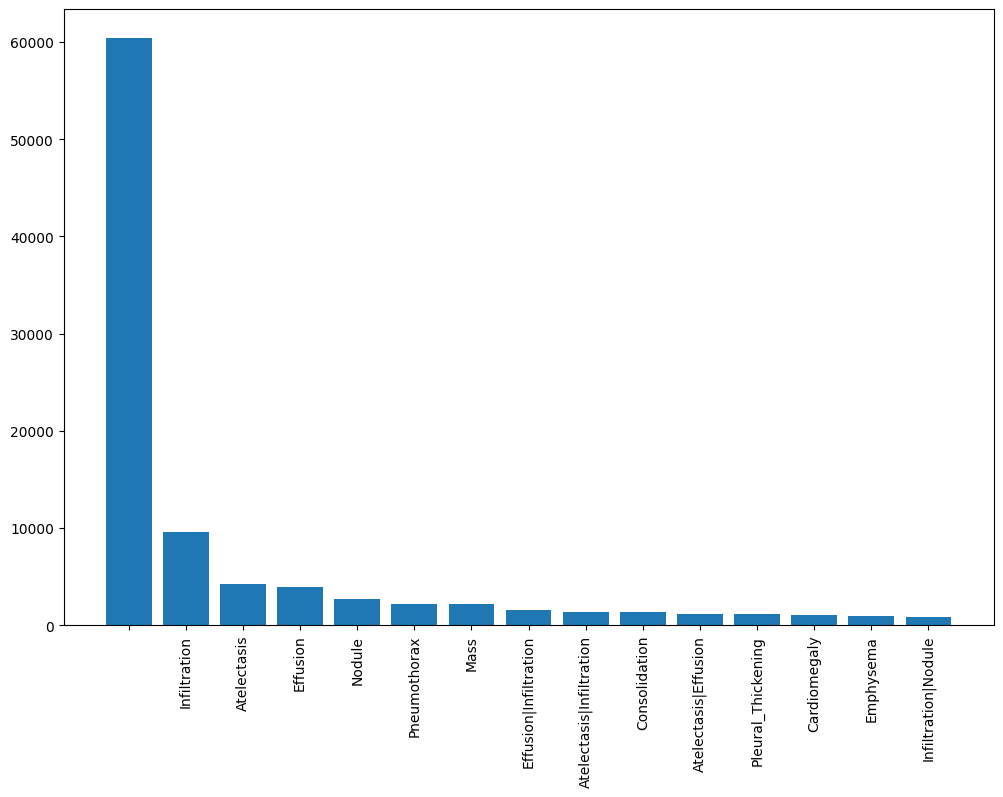

In [7]:
label_counts = csv['Finding Labels'].value_counts()[:15]
fig, ax1 = plt.subplots(1,1,figsize = (12, 8))
ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts)
ax1.set_xticks(np.arange(len(label_counts)) + 0.5)
_ = ax1.set_xticklabels(label_counts.index, rotation = 90)

In [8]:
sample_weights = csv['Finding Labels'].map(
    lambda x: len(x.split('|')) if len(x)>0 else 0
).values + 4e-2
sample_weights /= sample_weights.sum()

# # If you want to see the weight of each row:
# for index, weight in enumerate(sample_weights):
#   print(f"Row {index}| Weight: {weight}")
# print(f"Length of sample weights: {len(sample_weights)}")
# print(f"Number of rows in dataset: {csv.shape[0]}")

sampled_df = csv.sample(csv.shape[0] // 2, weights=sample_weights)

### Distribution after resampling

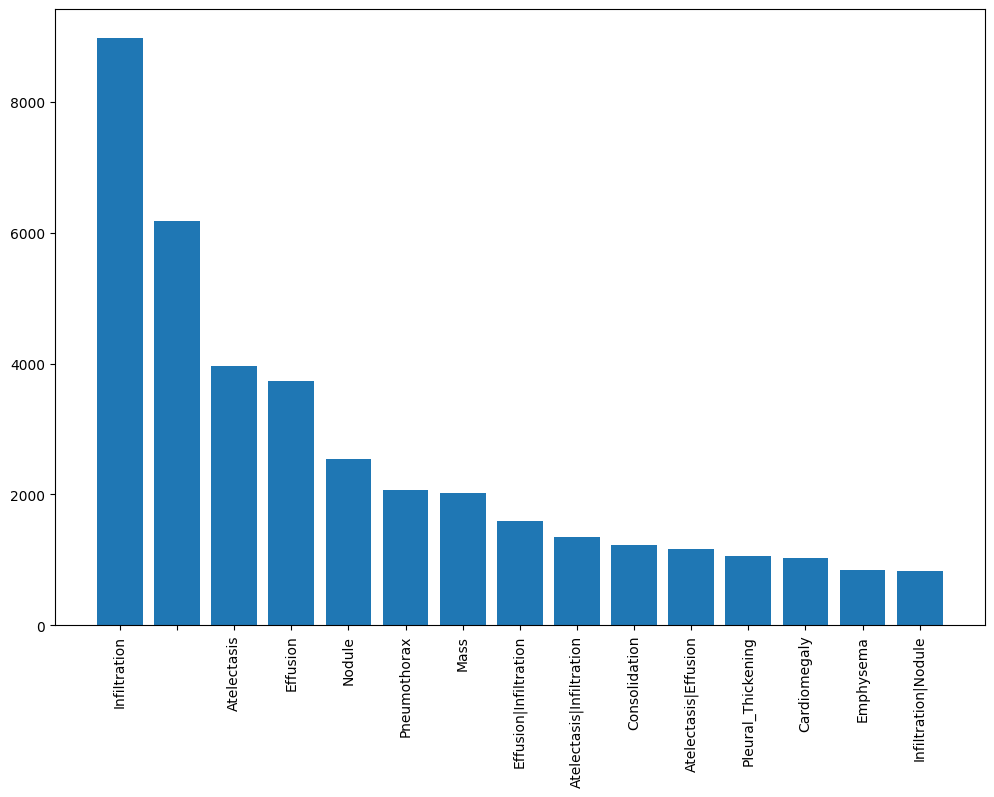

In [9]:
label_counts = sampled_df['Finding Labels'].value_counts()[:15]
fig, ax1 = plt.subplots(1,1,figsize = (12, 8))
ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts)
ax1.set_xticks(np.arange(len(label_counts)) + 0.5)
_ = ax1.set_xticklabels(label_counts.index, rotation = 90)

### Delete images that are not in the dataframe returned from sampling

In [ ]:
# Get images from the original dataframe that are not sampled
images_to_delete = csv[~csv["image_path"].isin(sampled_df["image_path"])]["image_path"].values

# Delete images
for image_path in tqdm(images_to_delete):
    if os.path.isfile(image_path):
        os.remove(image_path)

## Create a column containing the diseases as a list


In [11]:
sampled_df['disease_vec'] = sampled_df.apply(lambda x: x[all_labels].astype(int).values, axis=1)
print(sampled_df["disease_vec"])

12738     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
2901      [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0]
461       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0]
19302     [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
85488     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
                             ...                    
21357     [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
109322    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
94655     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
61519     [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
1825      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Name: disease_vec, Length: 56060, dtype: object


## Split the dataset

In [12]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(sampled_df,
                                   test_size = 0.15,
                                   random_state = 86196,
                                   stratify = sampled_df['Finding Labels'].map(lambda x: x[:4]))

train_df, validation_df = train_test_split(train_df,
                                   test_size = 0.10,
                                   random_state = 47941,
                                   stratify = train_df['Finding Labels'].map(lambda x: x[:4]))

print('Train:', train_df.shape[0], 'Validation:', validation_df.shape[0], 'Test:', test_df.shape[0])

Train: 42885 Validation: 4766 Test: 8409


## Get datasets of images

(1024, 1024, 3)


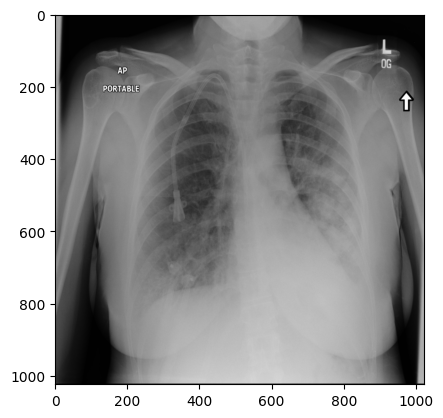

In [83]:
# Read an image using cv2
import cv2
img = cv2.imread(train_df["image_path"].iloc[0])

# Show using matplotlib
plt.imshow(img)

print(img.shape)

## Get datasets and augment data

In this step, we create datasets and apply data augmentations to improve model generalization. The augmentations include:

- Converting images to tensors with normalized pixel values.
- Random cropping (using 90% of the original image size) to add variation.
- Resizing to a fixed size of 640x640 for consistency.
- Random affine transformations (rotation and translation) to simulate different viewing angles (which are present in the original images).
- Applying Gaussian blur to mimic imaging noise.

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2 as transforms
from PIL import Image

IMAGE_SIZE = (640, 640)
ORIGINAL_IMAGE_SIZE = np.array(cv2.imread(train_df["image_path"].iloc[0]).shape[:2])
CROP_IMAGE_SIZE = (ORIGINAL_IMAGE_SIZE * 0.9).astype(int)

transform = transforms.Compose([
    transforms.ToTensor(), # image values will be scaled between 0 and 1
    transforms.RandomCrop(size=CROP_IMAGE_SIZE),
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomAffine(degrees=15, translate=(0.075, 0.075)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.5, 1.5)),
])

class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, path_column, y_column, transform=None):
        self.dataframe = dataframe
        self.path_column = path_column
        self.y_column = y_column
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        # Get the image path and label for the given index
        image_path = self.dataframe.iloc[index][self.path_column]
        label = self.dataframe.iloc[index][self.y_column]
        # Open image using PIL
        image = Image.open(image_path).convert("RGB")
        # Apply transformations
        if self.transform:
            image = self.transform(image)

        return image, label

def get_images_dataset_from_dataframe(dataframe: pd.DataFrame,
                                      path_column: str, y_column: str,
                                      batch_size: int) -> DataLoader:
    dataset = ChestXRayDataset(dataframe, path_column, y_column, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    return loader

train_dataset = get_images_dataset_from_dataframe(
    train_df,
    path_column="image_path",
    y_column="disease_vec",
    batch_size=16,
)
validation_dataset = get_images_dataset_from_dataframe(
    validation_df,
    path_column="image_path",
    y_column="disease_vec",
    batch_size=32,
)
test_dataset = get_images_dataset_from_dataframe(
    test_df,
    path_column="image_path",
    y_column="disease_vec",
    batch_size=64,
)

## Visualize the images from the datasets

*** BATCH 1 ***


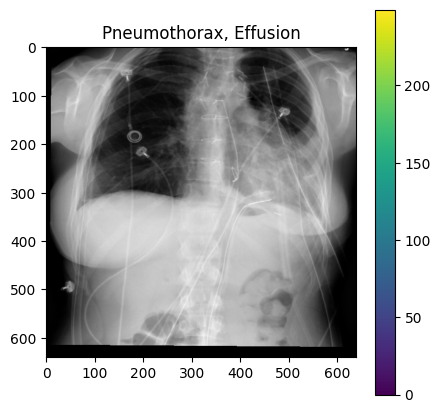

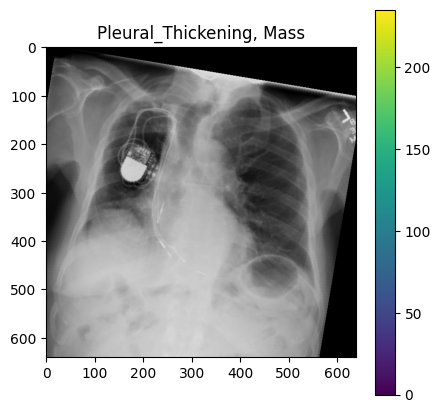

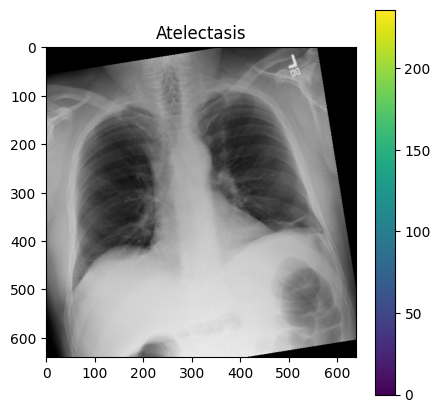

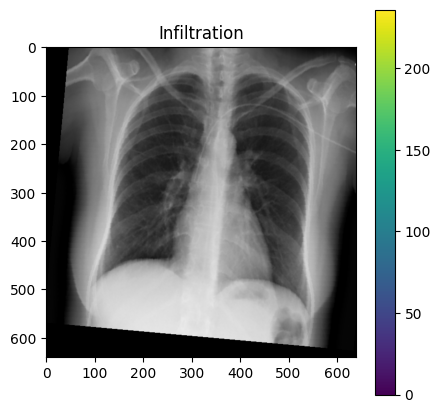

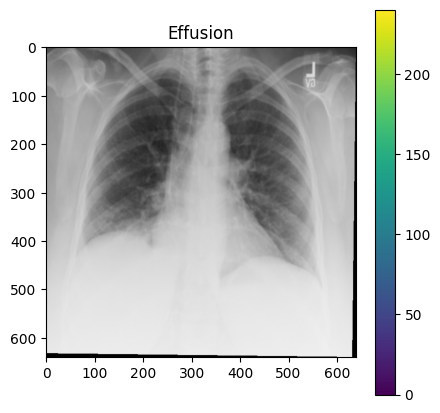

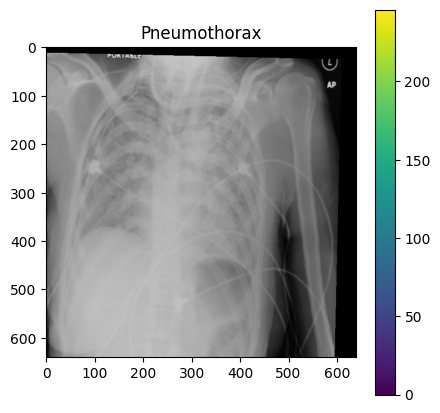

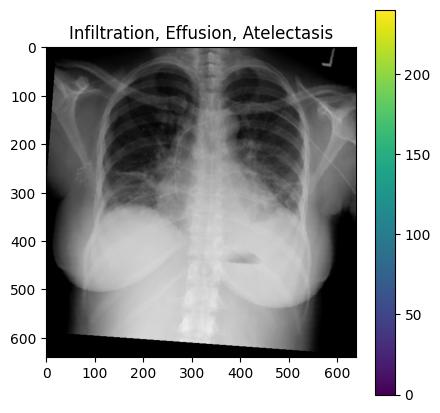

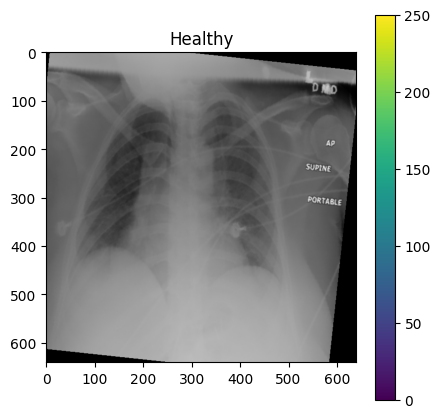

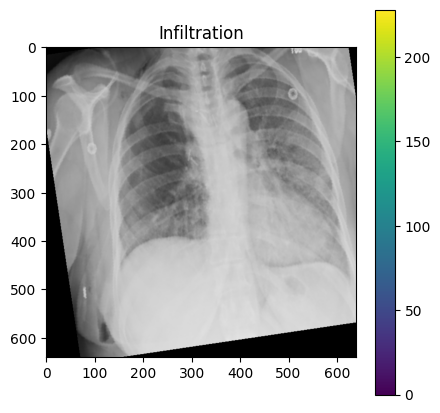

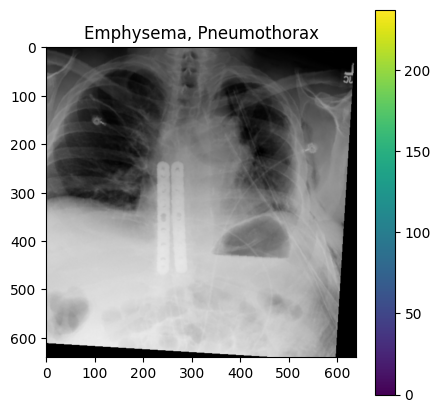

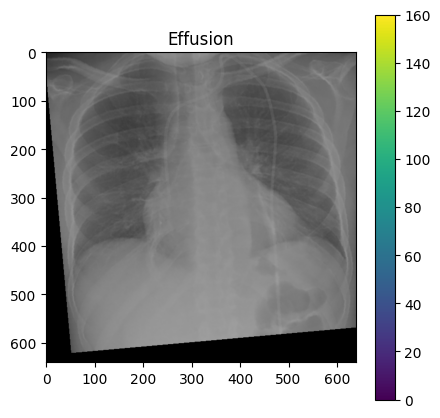

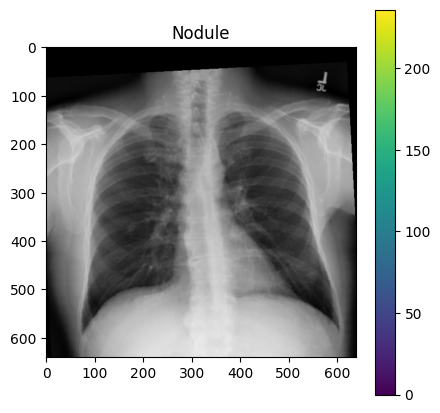

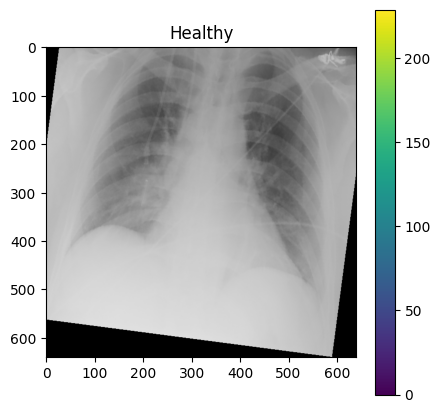

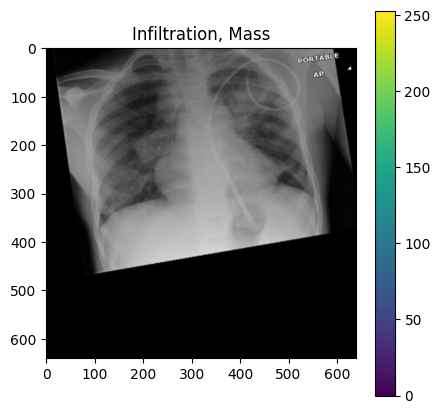

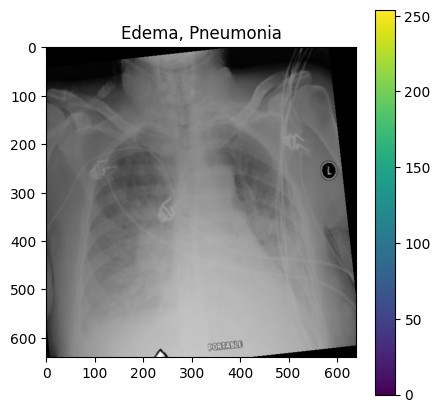

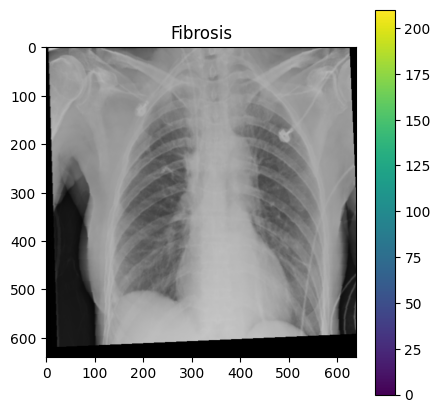

----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------

*** BATCH 2 ***


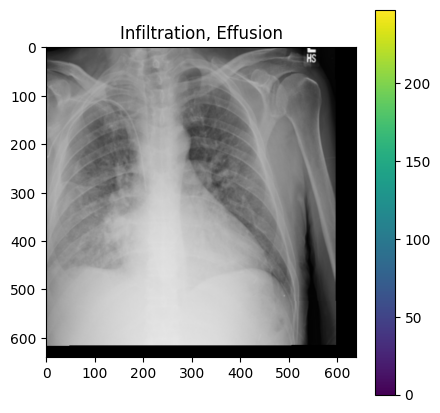

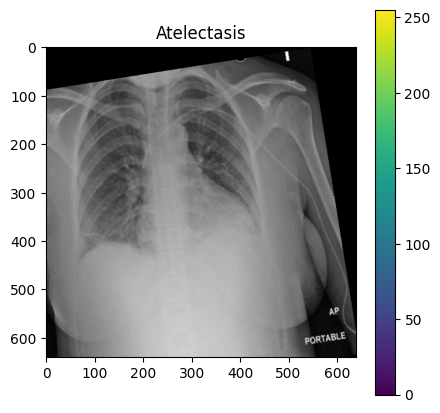

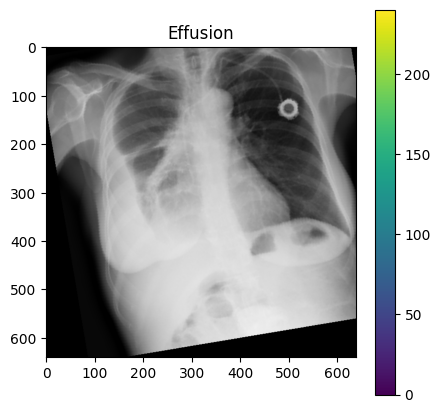

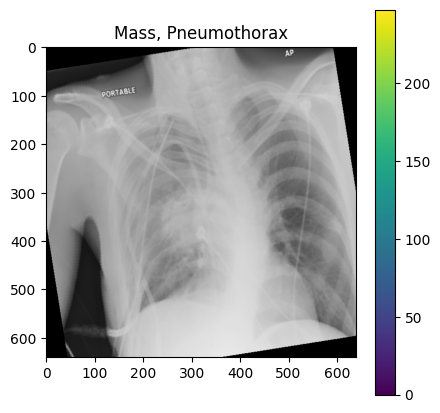

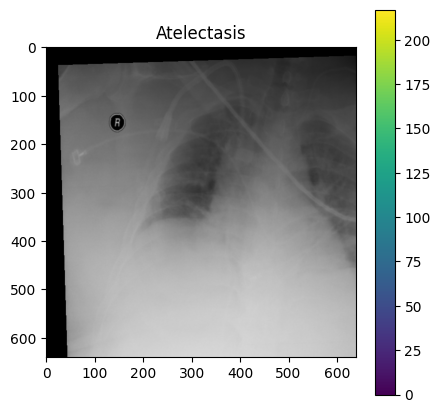

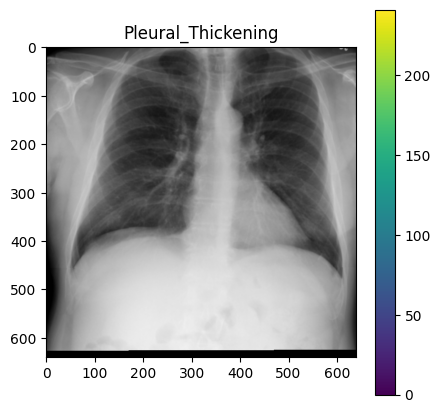

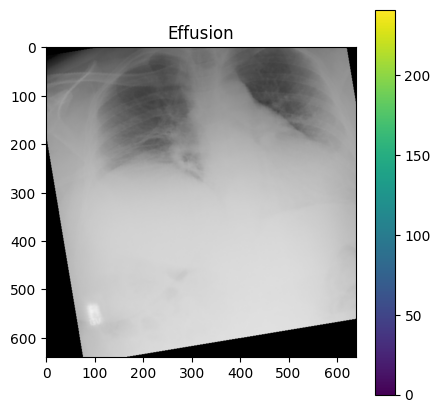

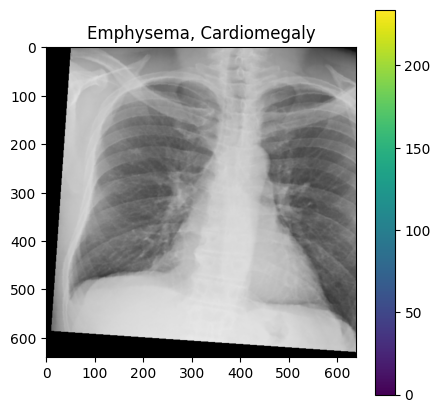

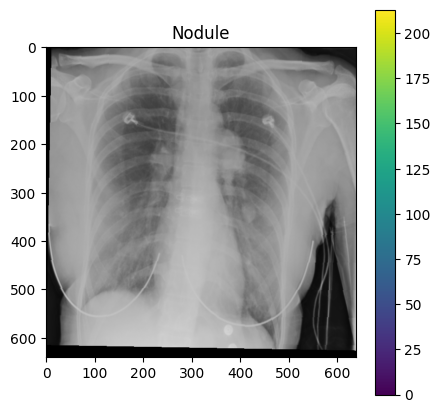

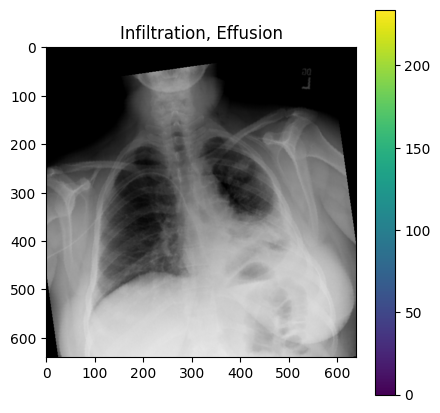

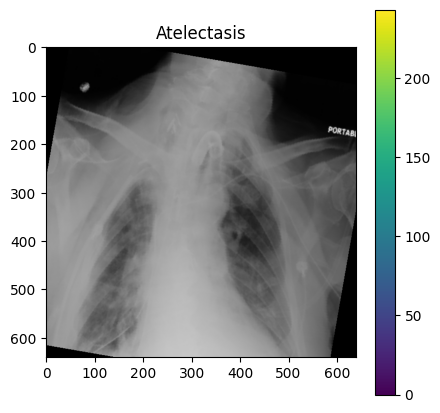

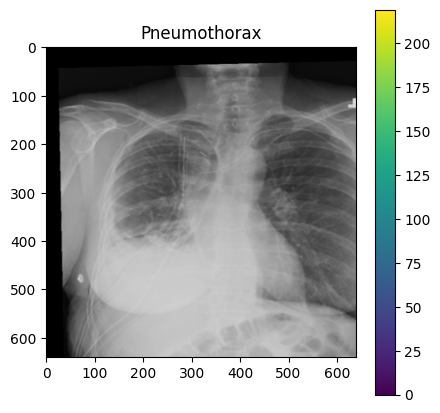

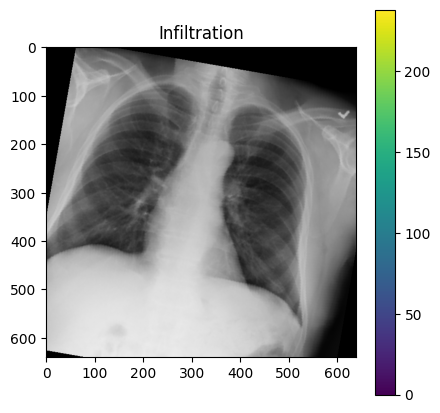

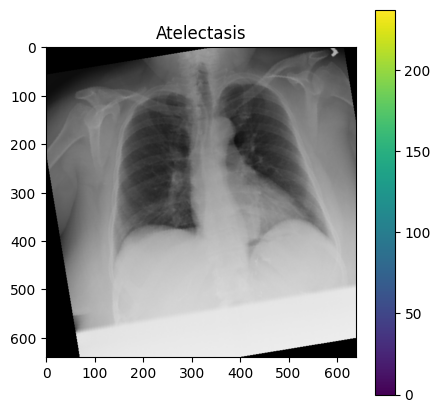

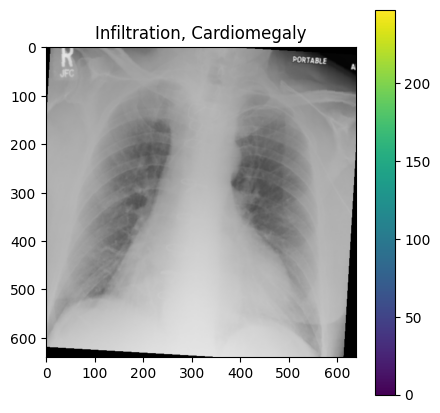

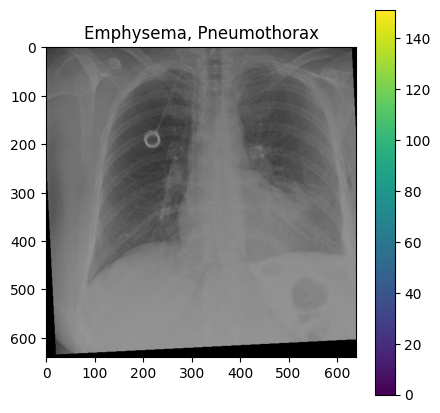

----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------



In [82]:
NUM_BATCHES_TO_SHOW = 2

for index, (images, labels) in enumerate(train_dataset):
    if index >= NUM_BATCHES_TO_SHOW:
        break
    print(f"*** BATCH {index+1} ***")
    for img, label in zip(images, labels):
        # Convert the one-hot label tensor to a list
        label = label.tolist()

        # Get all the Finding Labels corresponding to this image using one-hot encoding.
        finding_labels = [all_labels[i] for i, l in enumerate(label) if l == 1]
        if len(finding_labels) == 0:
            finding_labels = ["Healthy"]

        # Convert image tensor (C, H, W) to (H, W, C) for plotting and scale to 0-255 for visualization
        img_np = (img.permute(1, 2, 0).numpy() * 255).astype("uint8")

        plt.figure(figsize=(5,5))
        plt.imshow(img_np)
        plt.title(", ".join(finding_labels))
        plt.colorbar()
        plt.show()

    print("----------------------------------------------------------------\n" * 10)